# Bee Wing Classification with Superpixel Graph Neural Networks (GNN)

This notebook implements an end-to-end pipeline to classify bee wings by geographic origin:
1. **Direct SLIC Superpixel Segmentation**: Converts grayscale wing images directly into superpixel regions without brittle foreground silhouette masks.
2. **Region Adjacency Graph (RAG)**: Extracts 8 node features (spatial, geometric, intensity) and 5 edge features (spatial distance, boundary length, intensity contrast, relative orientation).
3. **Graph Neural Network (GNN)**: Trains a `GINEConv` network with edge attributes, JumpingKnowledge, and global pooling to classify wings directly from graph representations (not raw pixel grids).
4. **Disk Caching**: Processes images once and caches the graph dataset for fast iterative training.

## 1. Imports, Device & Configuration

In [5]:
import os
import json
import math
import copy
import time
from pathlib import Path
from dataclasses import dataclass, asdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage.segmentation import slic, mark_boundaries
from skimage.measure import regionprops
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, JumpingKnowledge, global_mean_pool, global_max_pool
from torch_geometric.transforms import BaseTransform

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Configuration
@dataclass
class Config:
    image_root: str = "bees"
    cache_dir: str = "cache_sp"
    max_side: int = 800          # longest side after isotropic downscale
    n_segments: int = 120        # target superpixel count
    compactness: float = 12.0    # balance between color proximity and space proximity
    slic_sigma: float = 1.0
    pca_align: bool = True       # orientation normalization
    node_dim: int = 8            # [x, y, r, area_frac, mean_i, std_i, ecc, sol]
    edge_dim: int = 5            # [cdist, bstrength, idiff, cos2t, sin2t]

CFG = Config()
print(CFG)


Using device: cpu
Config(image_root='bees', cache_dir='cache_sp', max_side=800, n_segments=120, compactness=12.0, slic_sigma=1.0, pca_align=True, node_dim=8, edge_dim=5)


## 2. Superpixel & Graph Extraction (No Foreground Silhouette)
We segment the wing image into superpixels using SLIC directly on the grayscale frame, eliminating brittle foreground silhouette masks.
We then construct a Region Adjacency Graph (RAG) connecting bordering superpixels, computing normalized node and edge features.

In [6]:
def load_gray(path, max_side=800):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Cannot read image: {path}")
    h, w = img.shape
    scale = max_side / float(max(h, w))
    if scale < 1.0:
        img = cv2.resize(img, (max(1, round(w * scale)), max(1, round(h * scale))),
                         interpolation=cv2.INTER_AREA)
    return img

def build_adjacency(labels):
    """Finds neighboring superpixel pairs and boundary contact counts."""
    h_a, h_b = labels[:, :-1].ravel(), labels[:, 1:].ravel()
    hm = (h_a != h_b) & (h_a > 0) & (h_b > 0)
    
    v_a, v_b = labels[:-1, :].ravel(), labels[1:, :].ravel()
    vm = (v_a != v_b) & (v_a > 0) & (v_b > 0)
    
    pa = np.concatenate([h_a[hm], v_a[vm]])
    pb = np.concatenate([h_b[hm], v_b[vm]])
    if len(pa) == 0:
        raise RuntimeError("No adjacent superpixel pairs found")
    
    lo, hi = np.minimum(pa, pb), np.maximum(pa, pb)
    n = int(labels.max()) + 1
    keys = lo.astype(np.int64) * n + hi.astype(np.int64)
    uniq, counts = np.unique(keys, return_counts=True)
    edges = np.stack([uniq // n, uniq % n], axis=1)
    return edges, counts.astype(np.float32)

def normalize_coordinates(xy, pca_align=True):
    """Centers and scales coordinates; applies PCA alignment for rotation invariance."""
    xy = xy - xy.mean(0, keepdims=True)
    scale = np.sqrt((xy ** 2).sum(1).mean())
    if scale < 1e-8:
        scale = 1.0
    xy = xy / scale
    if pca_align and len(xy) >= 3:
        cov = np.cov(xy.T)
        w, v = np.linalg.eigh(cov)
        xy = xy @ v[:, np.argsort(w)[::-1]]
        for k in range(2):
            if (xy[:, k] ** 3).sum() < 0:
                xy[:, k] *= -1.0
    return xy

def image_to_graph(path, cfg=CFG):
    """Converts a wing image directly into a superpixel graph representation."""
    gray = load_gray(path, cfg.max_side)
    # Direct SLIC segmentation - no foreground silhouette mask required
    labels = slic(gray.astype(np.float64), n_segments=cfg.n_segments,
                  compactness=cfg.compactness, sigma=cfg.slic_sigma,
                  channel_axis=None, start_label=1, enforce_connectivity=True)
    
    props = regionprops(labels, intensity_image=gray)
    if not props:
        raise RuntimeError(f"SLIC produced no superpixels for {path}")
    
    ids = [p.label for p in props]
    cy = np.array([p.centroid[0] for p in props], dtype=np.float32)
    cx = np.array([p.centroid[1] for p in props], dtype=np.float32)
    area = np.array([p.area for p in props], dtype=np.float32)
    total_area = float(gray.shape[0] * gray.shape[1])
    area_frac = (area / total_area) * 50.0
    
    mean_i = np.array([float(p.intensity_mean if hasattr(p, 'intensity_mean') else p.mean_intensity) for p in props], dtype=np.float32) / 255.0
    ecc = np.array([float(p.eccentricity) for p in props], dtype=np.float32)
    sol = np.array([float(p.solidity) for p in props], dtype=np.float32)
    std_i = ndi.standard_deviation(gray, labels, index=ids).astype(np.float32) / 255.0
    std_i = np.nan_to_num(std_i, nan=0.0)
    
    xy = normalize_coordinates(np.stack([cx, cy], 1), cfg.pca_align).astype(np.float32)
    r = np.linalg.norm(xy, axis=1, keepdims=True)
    
    # Node features: [x, y, r, area_frac, mean_i, std_i, eccentricity, solidity] (8 dims)
    x = np.concatenate([xy, r, area_frac[:, None], mean_i[:, None], std_i[:, None], ecc[:, None], sol[:, None]], axis=1)
    
    # Edges & Edge features
    edges, counts = build_adjacency(labels)
    edges0 = edges - 1  # 0-indexed
    
    d = xy[edges0[:, 1]] - xy[edges0[:, 0]]
    cdist = np.linalg.norm(d, axis=1)
    theta = np.arctan2(d[:, 1], d[:, 0])
    bstrength = counts / max(counts.mean(), 1e-8)
    bstrength = np.clip(bstrength, 0, 10)
    idiff = np.abs(mean_i[edges0[:, 1]] - mean_i[edges0[:, 0]])
    
    # Edge features: [cdist, bstrength, idiff, cos(2theta), sin(2theta)] (5 dims)
    ef = np.stack([cdist, bstrength, idiff, np.cos(2 * theta), np.sin(2 * theta)], 1).astype(np.float32)
    
    edge_index = np.concatenate([edges0, edges0[:, ::-1]], axis=0).T.astype(np.int64)
    edge_attr = np.concatenate([ef, ef], axis=0).astype(np.float32)
    
    return {
        "x": torch.from_numpy(x).float(),
        "edge_index": torch.from_numpy(edge_index).long(),
        "edge_attr": torch.from_numpy(edge_attr).float(),
        "pos": torch.from_numpy(xy).float(),
        "labels": labels,
        "gray": gray
    }


## 3. Quick Extraction Sanity Check
Visualize the superpixel boundaries and the region adjacency graph for a sample image.

Visualizing sample: bees\Austria\AT-0001-031-003678-L.dw.png


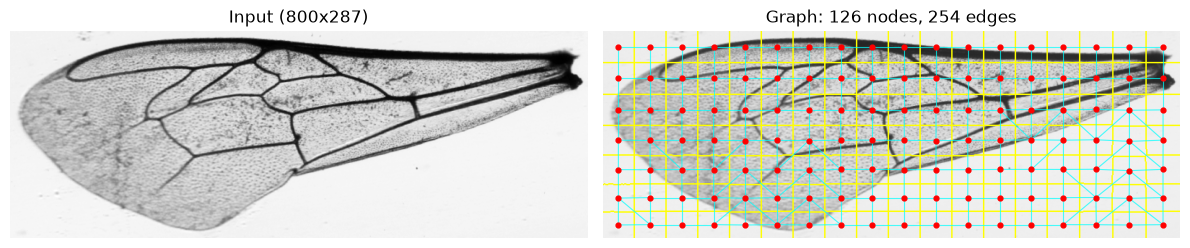

In [7]:
def visualize_extraction(image_path, cfg=CFG):
    res = image_to_graph(image_path, cfg)
    gray, labels = res["gray"], res["labels"]
    edges = res["edge_index"].numpy().T
    
    props = regionprops(labels)
    cy = np.array([p.centroid[0] for p in props])
    cx = np.array([p.centroid[1] for p in props])
    
    rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    vis = mark_boundaries(rgb, labels, color=(1, 1, 0), mode="thick")
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(gray, cmap="gray")
    ax[0].set_title(f"Input ({gray.shape[1]}x{gray.shape[0]})")
    ax[0].axis("off")
    
    ax[1].imshow(vis)
    for a, b in edges:
        if a < b:
            ax[1].plot([cx[a], cx[b]], [cy[a], cy[b]], "-", c="cyan", lw=0.8, alpha=0.7)
    ax[1].scatter(cx, cy, s=12, c="red", zorder=3)
    ax[1].set_title(f"Graph: {res['x'].shape[0]} nodes, {edges.shape[0]//2} edges")
    ax[1].axis("off")
    plt.tight_layout()
    plt.show()

sample_imgs = list(Path(CFG.image_root).glob("*/*.png"))
if sample_imgs:
    print(f"Visualizing sample: {sample_imgs[0]}")
    visualize_extraction(sample_imgs[0])


## 4. PyG Dataset with Automatic Disk Caching
`WingGraphDataset` automatically scans class folders, extracts graphs, and caches the dataset as `wings.pt`.

In [8]:
class WingGraphDataset(InMemoryDataset):
    def __init__(self, root, image_root=CFG.image_root, cfg=CFG, transform=None):
        self.image_root = Path(image_root)
        self.cfg = cfg
        super().__init__(root, transform)
        self.load(self.processed_paths[0])
        meta = json.loads(Path(self.processed_dir, "meta.json").read_text())
        self.classes = meta["classes"]
        self.paths = meta["paths"]

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return ["wings.pt", "meta.json"]

    def process(self):
        classes = sorted([d.name for d in self.image_root.iterdir() if d.is_dir() and not d.name.startswith(".")])
        image_exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
        samples = [(str(f), ci) for ci, c in enumerate(classes)
                   for f in sorted((self.image_root / c).iterdir()) if f.suffix.lower() in image_exts]
        
        data_list, kept = [], []
        print(f"Extracting graphs for {len(samples)} images across {len(classes)} classes...")
        t0 = time.time()
        for i, (path, label) in enumerate(samples, 1):
            try:
                g = image_to_graph(path, self.cfg)
                data = Data(x=g["x"], edge_index=g["edge_index"],
                            edge_attr=g["edge_attr"], pos=g["pos"],
                            y=torch.tensor([label], dtype=torch.long))
                data_list.append(data)
                kept.append(path)
            except Exception as e:
                print(f"  Failed {Path(path).name}: {e}")
            if i % 100 == 0 or i == len(samples):
                print(f"  [{i}/{len(samples)}] processed ({time.time() - t0:.1f}s)")
        
        os.makedirs(self.processed_dir, exist_ok=True)
        Path(self.processed_dir, "meta.json").write_text(
            json.dumps({"classes": classes, "paths": kept}, indent=2))
        self.save(data_list, self.processed_paths[0])
        print(f"Successfully saved {len(data_list)} graphs to {self.processed_paths[0]}")

# Load or extract dataset
t0 = time.time()
dataset = WingGraphDataset(CFG.cache_dir, CFG.image_root, CFG)
NUM_CLASSES = len(dataset.classes)
y_all = torch.cat([d.y for d in dataset]).numpy()
print(f"Loaded {len(dataset)} graphs across {NUM_CLASSES} classes in {time.time() - t0:.2f}s")
print("Classes:", dataset.classes)
print("Distribution:", {c: int((y_all == i).sum()) for i, c in enumerate(dataset.classes)})


Processing...


Extracting graphs for 915 images across 5 classes...
  [100/915] processed (29.1s)
  [200/915] processed (61.7s)
  [300/915] processed (103.9s)
  [400/915] processed (141.5s)
  [500/915] processed (171.8s)
  [600/915] processed (202.4s)
  [700/915] processed (234.8s)
  [800/915] processed (277.5s)
  [900/915] processed (305.2s)
  [915/915] processed (309.6s)
Successfully saved 915 graphs to cache_sp\processed\wings.pt
Loaded 915 graphs across 5 classes in 309.85s
Classes: ['Austria', 'Greece', 'Hungary', 'Moldova', 'Morocco']
Distribution: {'Austria': 183, 'Greece': 183, 'Hungary': 183, 'Moldova': 183, 'Morocco': 183}


Done!


## 5. Lightweight Graph Augmentations & Dataset Splitting
Concise spatial rotation, jitter, and feature noise transforms regularize training.
We split the data into Stratified Train (70%), Validation (15%), and Test (15%) subsets.

In [9]:
class GraphAugment(BaseTransform):
    """Concise graph augmentation: 2D coordinate rotation, spatial jitter, and feature noise."""
    def __init__(self, max_deg=15.0, jitter=0.02, noise=0.02):
        self.max_rad = math.radians(max_deg)
        self.jitter = jitter
        self.noise = noise

    def forward(self, data):
        # 1. 2D Coordinate Rotation
        theta = (torch.rand(1).item() * 2 - 1) * self.max_rad
        cos_t, sin_t = math.cos(theta), math.sin(theta)
        R = torch.tensor([[cos_t, -sin_t], [sin_t, cos_t]], dtype=data.x.dtype)
        data.x[:, 0:2] = data.x[:, 0:2] @ R.T
        if hasattr(data, "pos") and data.pos is not None:
            data.pos = data.pos @ R.T
        if data.edge_attr is not None and data.edge_attr.size(1) >= 5:
            cos2, sin2 = data.edge_attr[:, 3].clone(), data.edge_attr[:, 4].clone()
            c2, s2 = math.cos(2 * theta), math.sin(2 * theta)
            data.edge_attr[:, 3] = cos2 * c2 - sin2 * s2
            data.edge_attr[:, 4] = cos2 * s2 + sin2 * c2
        # 2. Position Jitter
        if self.jitter > 0:
            data.x[:, 0:2] += torch.randn_like(data.x[:, 0:2]) * self.jitter
            data.x[:, 2] = data.x[:, 0:2].norm(dim=1)  # update radius r
        # 3. Feature Noise
        if self.noise > 0:
            data.x[:, 3:] += torch.randn_like(data.x[:, 3:]) * self.noise
        return data

TRAIN_TRANSFORM = GraphAugment(max_deg=15.0, jitter=0.02, noise=0.02)

# Stratified Train (70%), Val (15%), Test (15%) split
idx = np.arange(len(dataset))
tr_idx, te_idx = train_test_split(idx, test_size=0.15, stratify=y_all, random_state=SEED)
tr_idx, va_idx = train_test_split(tr_idx, test_size=0.1765, stratify=y_all[tr_idx], random_state=SEED)
print(f"Splits: {len(tr_idx)} train | {len(va_idx)} val | {len(te_idx)} test")

def get_subset(indices, transform=None):
    sub = dataset[torch.as_tensor(np.asarray(indices), dtype=torch.long)]
    sub.transform = transform
    return sub


Splits: 639 train | 138 val | 138 test


## 6. Wing Graph Neural Network (`WingGNN`)
`WingGNN` leverages `GINEConv` to propagate messages incorporating both node and edge features, followed by JumpingKnowledge aggregation and global pooling.

In [10]:
def make_mlp(in_dim, hidden_dim, out_dim):
    return nn.Sequential(
        nn.Linear(in_dim, hidden_dim),
        nn.BatchNorm1d(hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, out_dim)
    )

class WingGNN(nn.Module):
    def __init__(self, num_classes, node_dim=CFG.node_dim, edge_dim=CFG.edge_dim,
                 hidden=128, layers=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.node_enc = nn.Sequential(nn.Linear(node_dim, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        self.edge_enc = nn.Sequential(nn.Linear(edge_dim, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        
        self.convs = nn.ModuleList([
            GINEConv(make_mlp(hidden, hidden, hidden), train_eps=True, edge_dim=hidden)
            for _ in range(layers)
        ])
        self.norms = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(layers)])
        self.jk = JumpingKnowledge("cat")
        
        self.head = nn.Sequential(
            nn.Linear(hidden * layers * 2, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, num_classes)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        
        h = self.node_enc(x)
        e = self.edge_enc(edge_attr)
        
        hs = []
        for conv, norm in zip(self.convs, self.norms):
            h_in = h
            h = F.dropout(F.relu(norm(conv(h, edge_index, e))), p=self.dropout, training=self.training) + h_in
            hs.append(h)
            
        h_all = self.jk(hs)
        pool = torch.cat([global_mean_pool(h_all, batch), global_max_pool(h_all, batch)], dim=1)
        return self.head(pool)

model = WingGNN(NUM_CLASSES).to(DEVICE)
print(f"WingGNN instantiated: {sum(p.numel() for p in model.parameters()):,} parameters")


WingGNN instantiated: 375,177 parameters


## 7. Model Training & Optimization
We train using AdamW with OneCycleLR scheduling, class-imbalance weighting, and early stopping on validation macro-F1.

In [11]:
BATCH_SIZE = 32
LR = 3e-3
EPOCHS = 120
PATIENCE = 30

train_loader = DataLoader(get_subset(tr_idx, TRAIN_TRANSFORM), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(get_subset(va_idx, None), batch_size=BATCH_SIZE * 2)
test_loader = DataLoader(get_subset(te_idx, None), batch_size=BATCH_SIZE * 2)

# Class weights to handle any minor imbalance
class_counts = np.bincount(y_all[tr_idx], minlength=NUM_CLASSES).astype(float)
class_weights = torch.tensor(class_counts.sum() / (NUM_CLASSES * np.maximum(class_counts, 1)),
                             dtype=torch.float32, device=DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR, total_steps=EPOCHS, pct_start=0.15)

def run_epoch(m, loader, opt=None):
    is_train = opt is not None
    m.train(is_train)
    total_loss, preds, trues = 0.0, [], []
    for b in loader:
        b = b.to(DEVICE)
        with torch.set_grad_enabled(is_train):
            out = m(b)
            loss = F.cross_entropy(out, b.y, weight=class_weights, label_smoothing=0.05 if is_train else 0.0)
        if is_train:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 2.0)
            opt.step()
        total_loss += float(loss) * b.num_graphs
        preds.append(out.argmax(1).cpu())
        trues.append(b.y.cpu())
    p, t = torch.cat(preds).numpy(), torch.cat(trues).numpy()
    return total_loss / len(t), (p == t).mean(), f1_score(t, p, average="macro")

best_f1, best_weights, bad_epochs, history = -1.0, None, 0, []
print("Starting training...")
t0 = time.time()
for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, optimizer)
    va_loss, va_acc, va_f1 = run_epoch(model, val_loader)
    scheduler.step()
    history.append((ep, tr_loss, tr_f1, va_loss, va_f1))
    
    if va_f1 > best_f1:
        best_f1 = va_f1
        best_weights = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        
    if ep % 10 == 0 or ep == 1:
        print(f"Ep {ep:3d} | Train Loss: {tr_loss:.3f} F1: {tr_f1:.3f} | Val Loss: {va_loss:.3f} Acc: {va_acc:.3f} F1: {va_f1:.3f} (Best: {best_f1:.3f})")
    if bad_epochs >= PATIENCE:
        print(f"Early stopping at epoch {ep}. Best validation macro-F1: {best_f1:.3f}")
        break

print(f"Training finished in {time.time() - t0:.1f}s")
if best_weights is not None:
    model.load_state_dict(best_weights)


Starting training...


C:\Users\Amine\AppData\Local\Temp\ipykernel_10808\4054062813.py:32: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:821.)
  total_loss += float(loss) * b.num_graphs


Ep   1 | Train Loss: 1.571 F1: 0.238 | Val Loss: 1.631 Acc: 0.203 F1: 0.067 (Best: 0.067)
Ep  10 | Train Loss: 0.478 F1: 0.915 | Val Loss: 2.728 Acc: 0.217 F1: 0.107 (Best: 0.477)
Ep  20 | Train Loss: 0.355 F1: 0.966 | Val Loss: 0.693 Acc: 0.797 F1: 0.745 (Best: 0.745)
Ep  30 | Train Loss: 0.295 F1: 0.991 | Val Loss: 1.997 Acc: 0.268 F1: 0.188 (Best: 0.745)
Ep  40 | Train Loss: 0.323 F1: 0.978 | Val Loss: 0.931 Acc: 0.775 F1: 0.706 (Best: 0.816)
Ep  50 | Train Loss: 0.266 F1: 0.994 | Val Loss: 0.800 Acc: 0.587 F1: 0.571 (Best: 0.874)
Ep  60 | Train Loss: 0.269 F1: 0.995 | Val Loss: 0.774 Acc: 0.659 F1: 0.598 (Best: 0.874)
Ep  70 | Train Loss: 0.258 F1: 0.997 | Val Loss: 1.368 Acc: 0.486 F1: 0.389 (Best: 0.957)
Ep  80 | Train Loss: 0.252 F1: 1.000 | Val Loss: 1.171 Acc: 0.399 F1: 0.358 (Best: 0.957)
Ep  90 | Train Loss: 0.252 F1: 0.998 | Val Loss: 0.830 Acc: 0.572 F1: 0.526 (Best: 0.957)
Early stopping at epoch 97. Best validation macro-F1: 0.957
Training finished in 259.1s


## 8. Evaluation & Test Set Performance
We plot the learning curves, compute accuracy and macro-F1 on the held-out test set, and display the confusion matrix.

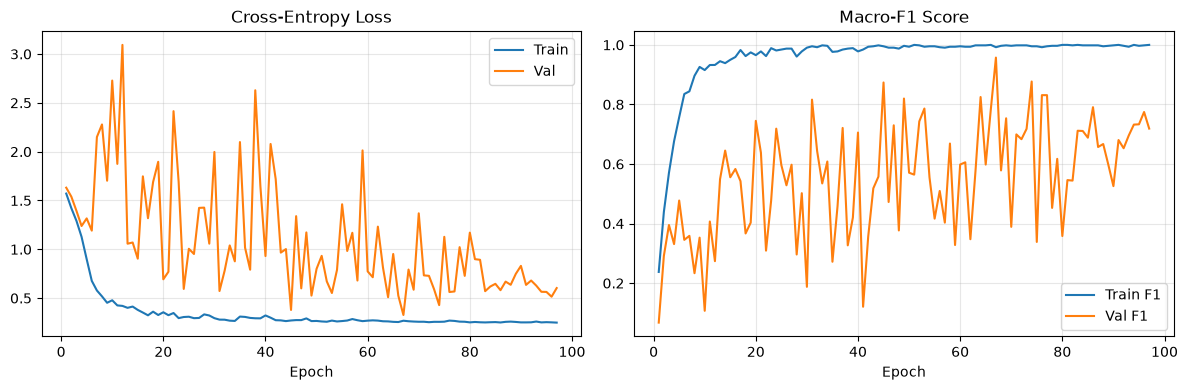

=== TEST RESULTS: Accuracy = 0.9783 | Macro-F1 = 0.9781 ===

              precision    recall  f1-score   support

     Austria      1.000     1.000     1.000        28
      Greece      0.900     1.000     0.947        27
     Hungary      1.000     0.964     0.982        28
     Moldova      1.000     1.000     1.000        28
     Morocco      1.000     0.926     0.962        27

    accuracy                          0.978       138
   macro avg      0.980     0.978     0.978       138
weighted avg      0.980     0.978     0.978       138



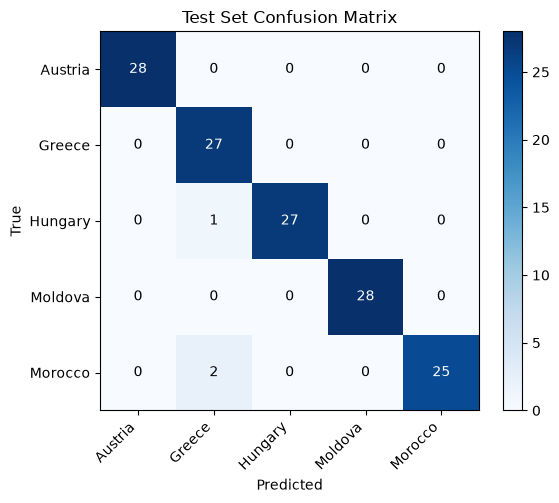

In [12]:
# 1. Plot learning curves
hist = np.array(history, dtype=float)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist[:, 0], hist[:, 1], label="Train")
ax[0].plot(hist[:, 0], hist[:, 3], label="Val")
ax[0].set_title("Cross-Entropy Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(hist[:, 0], hist[:, 2], label="Train F1")
ax[1].plot(hist[:, 0], hist[:, 4], label="Val F1")
ax[1].set_title("Macro-F1 Score"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 2. Evaluate on held-out test set
model.eval()
test_loss, test_acc, test_f1 = run_epoch(model, test_loader)
print(f"=== TEST RESULTS: Accuracy = {test_acc:.4f} | Macro-F1 = {test_f1:.4f} ===\n")

all_preds, all_trues = [], []
with torch.no_grad():
    for b in test_loader:
        b = b.to(DEVICE)
        all_preds.append(model(b).argmax(1).cpu())
        all_trues.append(b.y.cpu())
p = torch.cat(all_preds).numpy()
t = torch.cat(all_trues).numpy()

print(classification_report(t, p, target_names=dataset.classes, digits=3))

# 3. Confusion Matrix Plot
cm = confusion_matrix(t, p, labels=range(NUM_CLASSES))
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(cm, cmap="Blues")
plt.colorbar(cax)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(dataset.classes, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES))
ax.set_yticklabels(dataset.classes)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Test Set Confusion Matrix")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.show()


## 9. Save Checkpoint & Single-Image Inference
Save the trained model and predict the geographic origin of unseen bee wing images.

In [13]:
CHECKPOINT_PATH = "wing_gnn_model.pt"
torch.save({
    "state_dict": model.state_dict(),
    "classes": dataset.classes,
    "cfg": asdict(CFG)
}, CHECKPOINT_PATH)
print(f"Checkpoint saved to {CHECKPOINT_PATH}")

@torch.no_grad()
def predict_wing(image_path, model=model, classes=dataset.classes, cfg=CFG):
    """Predicts the origin of an unseen wing image directly by converting it to a superpixel graph."""
    model.eval()
    g = image_to_graph(image_path, cfg)
    data = Data(x=g["x"], edge_index=g["edge_index"], edge_attr=g["edge_attr"], pos=g["pos"])
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long)
    data = data.to(DEVICE)
    
    logits = model(data)
    probs = F.softmax(logits, dim=1).cpu().numpy()[0]
    best_idx = np.argmax(probs)
    return classes[best_idx], float(probs[best_idx]), {c: float(p) for c, p in zip(classes, probs)}

# Test inference on a sample
sample_test_path = dataset.paths[te_idx[0]]
pred_cls, conf, all_probs = predict_wing(sample_test_path)
print(f"Image: {Path(sample_test_path).name}")
print(f"True Region: {dataset.classes[dataset[te_idx[0]].y.item()]}")
print(f"Predicted Region: {pred_cls} (Confidence: {conf*100:.1f}%)")
print("Probabilities:", {k: f"{v:.3f}" for k, v in all_probs.items()})


Checkpoint saved to wing_gnn_model.pt
Image: AT-0006-102-003641-R.dw.png
True Region: Austria
Predicted Region: Austria (Confidence: 76.3%)
Probabilities: {'Austria': '0.763', 'Greece': '0.070', 'Hungary': '0.047', 'Moldova': '0.075', 'Morocco': '0.045'}


c:\Users\Amine\.conda\envs\studenv\Lib\site-packages\scipy\ndimage\_measurements.py:647: RuntimeWarning: invalid value encountered in divide
  means = sums / counts
